In [20]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [2]:
def all_pairs(nodes):
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i < j:
                yield u, v

In [3]:
def flip(p):
    return np.random.random() < p

In [4]:
def random_pairs(nodes, p):
    for edge in all_pairs(nodes):
        if flip(p):
            yield edge

In [5]:
def make_random_graph(n, p):
    G = nx.Graph()
    nodes = range(n)
    G.add_nodes_from(nodes)
    G.add_edges_from(random_pairs(nodes, p))
    return G

In [6]:
random_graph = make_random_graph(10, .3)


In [7]:
def reachable_nodes(G, start):
    seen = set()
    stack = [start]
    while stack:
        node = stack.pop()
        if node not in seen:
            seen.add(node)
            stack.extend(G.neighbors(node))
    return seen

In [8]:
def is_connected(G):
    start = next(iter(G))
    reachable = reachable_nodes(G, start)
    return len(reachable) == len(G)

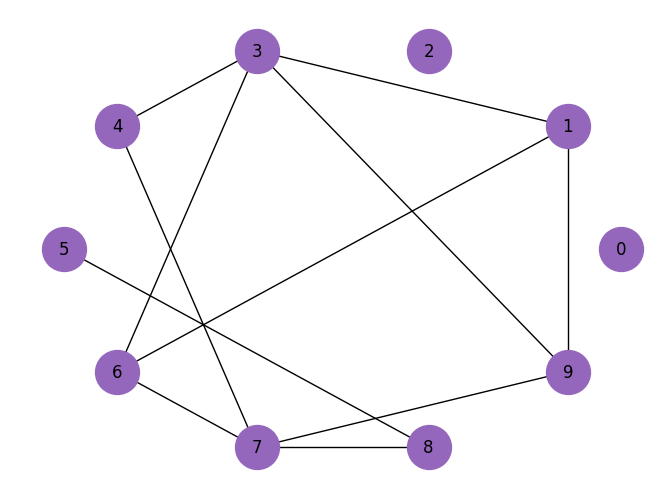

In [9]:
nx.draw_circular(random_graph, 
                 node_color='C4', 
                 node_size=1000, 
                 with_labels=True)


In [12]:
def prob_connected(n, p, iters=100):
    tf = [is_connected(make_random_graph(n, p))
          for i in range(iters)]
    return np.mean(tf)

In [13]:
np.random.seed(17)

n= 10
prob_connected(n, 0.23, iters=1000)

np.float64(0.342)

In [14]:
pstar = np.log(n) / n
pstar

np.float64(0.23025850929940458)

In [15]:
ps = np.logspace(-1.3, 0, 11)
ps

array([0.05011872, 0.0676083 , 0.09120108, 0.12302688, 0.16595869,
       0.22387211, 0.30199517, 0.40738028, 0.54954087, 0.74131024,
       1.        ])

In [17]:
ys = [prob_connected(n, p, 1000) for p in ps]

for p, y in zip(ps, ys):
    print(p, y)

0.05011872336272722 0.001
0.06760829753919818 0.0
0.09120108393559097 0.003
0.12302687708123815 0.019
0.16595869074375605 0.1
0.22387211385683395 0.302
0.3019951720402016 0.683
0.40738027780411273 0.915
0.5495408738576245 0.994
0.7413102413009173 1.0
1.0 1.0


In [18]:
plt.axvline(pstar, color='gray')
plt.plot(ps, ys, color='green')
decorate(xlabel='Prob of edge (p)',
                 ylabel='Prob connected',
                 xscale='log')

savefig('figs/chap02-5')

NameError: name 'plt' is not defined